In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


In [5]:
df = pd.read_csv("Online Retail.csv")

print("Original dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Original dataset shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
print("Dataset Information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nQuantity statistics:")
print(df["Quantity"].describe())

print("\nUnitPrice statistics:")
print(df["UnitPrice"].describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268

Quantity statistics:
count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%        

In [7]:

# Detailed data quality analysis

# Convert InvoiceDate to datetime for analysis
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True,
    errors="coerce"
)

# Missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Invalid quantities
print("\nQuantity <= 0:")
print((df["Quantity"] <= 0).sum())

print("Negative Quantity:")
print((df["Quantity"] < 0).sum())

print("Zero Quantity:")
print((df["Quantity"] == 0).sum())

# Invalid prices
print("\nUnitPrice <= 0:")
print((df["UnitPrice"] <= 0).sum())

print("Negative UnitPrice:")
print((df["UnitPrice"] < 0).sum())

print("Zero UnitPrice:")
print((df["UnitPrice"] == 0).sum())

# Cancellation invoices
cancellation_count = (
    df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print("\nCancellation invoices:")
print(cancellation_count)

# Date range
print("\nInvoiceDate range:")
print(df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268

Quantity <= 0:
10624
Negative Quantity:
10624
Zero Quantity:
0

UnitPrice <= 0:
2517
Negative UnitPrice:
2
Zero UnitPrice:
2515

Cancellation invoices:
9288

InvoiceDate range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [8]:
# Data cleaning

clean_df = df.copy()

# 1. Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# 2. Remove rows with missing product description
clean_df = clean_df.dropna(subset=["Description"])

# 3. Remove rows with missing customer ID
clean_df = clean_df.dropna(subset=["CustomerID"])

# 4. Remove cancellation invoices
clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

# 5. Keep only positive quantities
clean_df = clean_df[clean_df["Quantity"] > 0]

# 6. Keep only positive unit prices
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# 7. Convert CustomerID to integer
clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)

# 8. Create transaction amount
clean_df["TotalAmount"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

print("Cleaned dataset shape:", clean_df.shape)
print("Rows removed:", len(df) - len(clean_df))
print("Rows retained:", len(clean_df))
print("Retention percentage:", round(len(clean_df) / len(df) * 100, 2))

Cleaned dataset shape: (392692, 9)
Rows removed: 149217
Rows retained: 392692
Retention percentage: 72.46


In [9]:
# Validate cleaned dataset

print("Missing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(clean_df.duplicated().sum())

print("\nMinimum Quantity:")
print(clean_df["Quantity"].min())

print("\nMinimum UnitPrice:")
print(clean_df["UnitPrice"].min())

print("\nCancellation invoices remaining:")
print(
    clean_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print("\nFinal columns:")
print(clean_df.columns.tolist())

print("\nFinal data types:")
print(clean_df.dtypes)

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate rows after cleaning:
0

Minimum Quantity:
1

Minimum UnitPrice:
0.001

Cancellation invoices remaining:
0

Final columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']

Final data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalAmount           float64
dtype: object


In [10]:
# Feature engineering

clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["Day"] = clean_df["InvoiceDate"].dt.day
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

print("Feature engineering completed.")
print("Final dataset shape:", clean_df.shape)

display(clean_df.head())

Feature engineering completed.
Final dataset shape: (392692, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8


In [11]:
# Overall EDA summary

total_revenue = clean_df["TotalAmount"].sum()
total_quantity = clean_df["Quantity"].sum()
unique_customers = clean_df["CustomerID"].nunique()
unique_invoices = clean_df["InvoiceNo"].nunique()
unique_products = clean_df["StockCode"].nunique()
unique_countries = clean_df["Country"].nunique()

print("=== Overall EDA Summary ===")
print("Total transaction amount:", round(total_revenue, 2))
print("Total quantity sold:", total_quantity)
print("Unique customers:", unique_customers)
print("Unique invoices:", unique_invoices)
print("Unique products:", unique_products)
print("Unique countries:", unique_countries)

print("\nDate range:")
print(clean_df["InvoiceDate"].min(), "to", clean_df["InvoiceDate"].max())

=== Overall EDA Summary ===
Total transaction amount: 8887208.89
Total quantity sold: 5152002
Unique customers: 4338
Unique invoices: 18532
Unique products: 3665
Unique countries: 37

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00


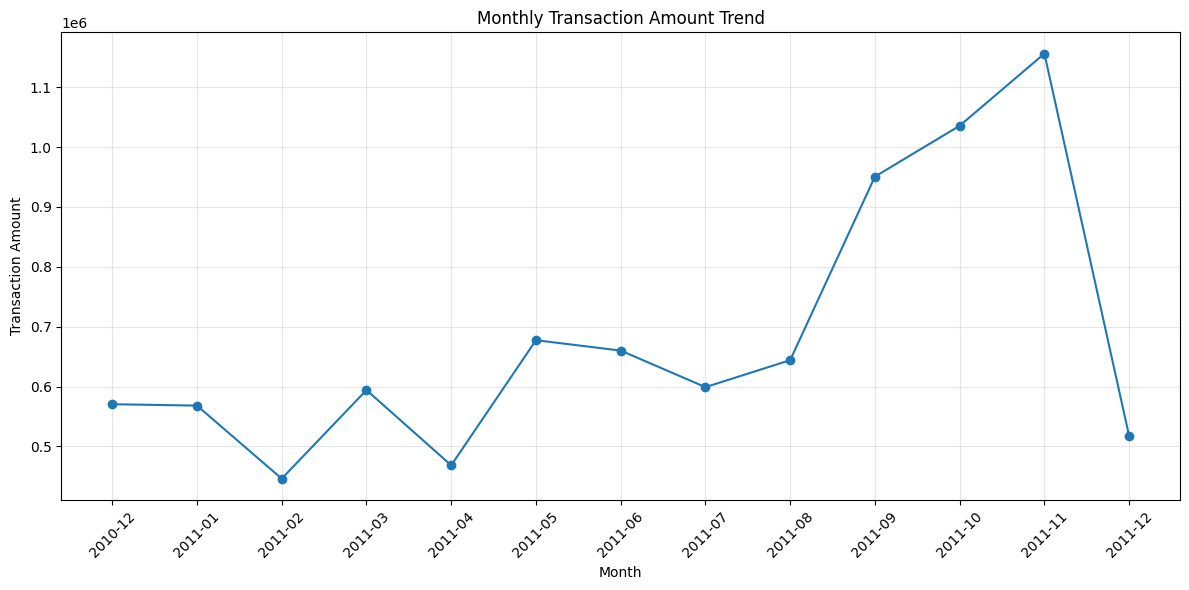

In [12]:
# Monthly transaction amount

monthly_revenue = (
    clean_df.groupby(["Year", "Month"])["TotalAmount"]
    .sum()
    .reset_index()
)

monthly_revenue["Period"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Period"],
    monthly_revenue["TotalAmount"],
    marker="o"
)

plt.title("Monthly Transaction Amount Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

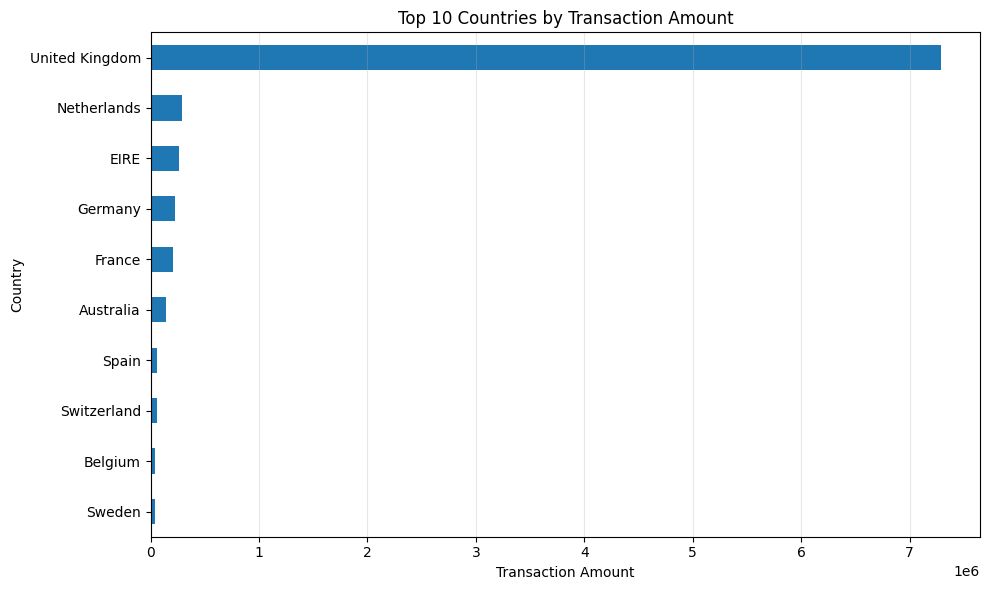

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64


In [13]:
# Top 10 countries by transaction amount

country_revenue = (
    clean_df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Country")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(country_revenue)

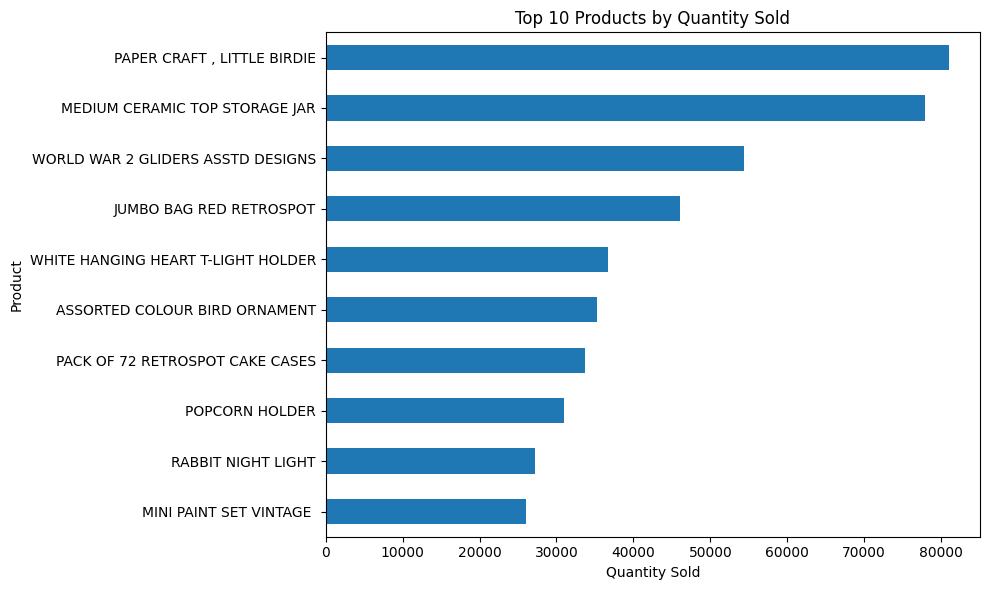

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [14]:
# Top 10 products by quantity sold

product_quantity = (
    clean_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

product_quantity.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

print(product_quantity)

Customer purchase frequency statistics:
count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


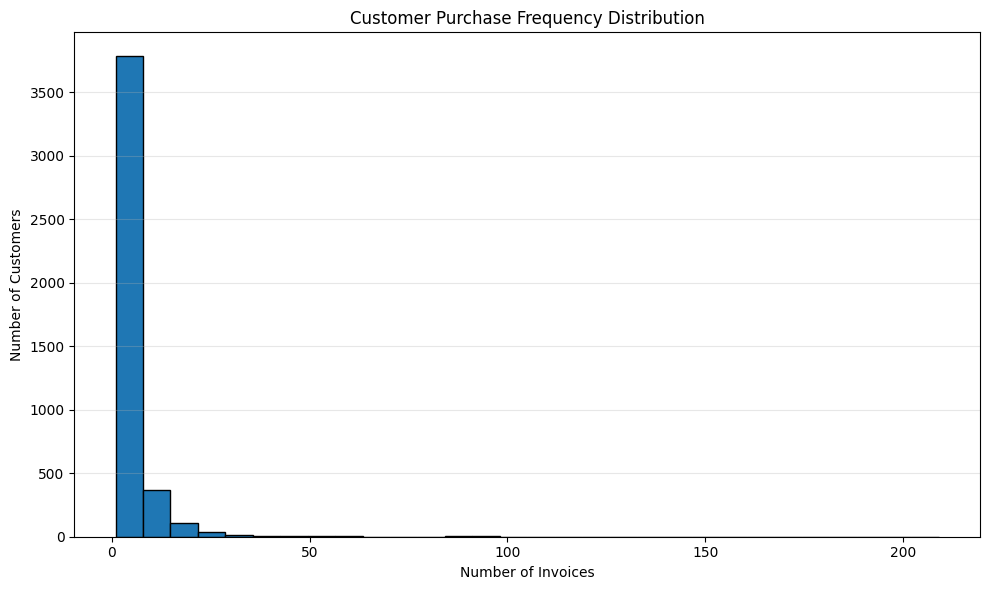

In [15]:
# Customer purchase frequency

customer_frequency = (
    clean_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

print("Customer purchase frequency statistics:")
print(customer_frequency.describe())

plt.figure(figsize=(10, 6))

plt.hist(
    customer_frequency,
    bins=30,
    edgecolor="black"
)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Invoices")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Correlation Matrix:


,Quantity,UnitPrice,TotalAmount
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
TotalAmount,0.914451,0.081619,1.000000


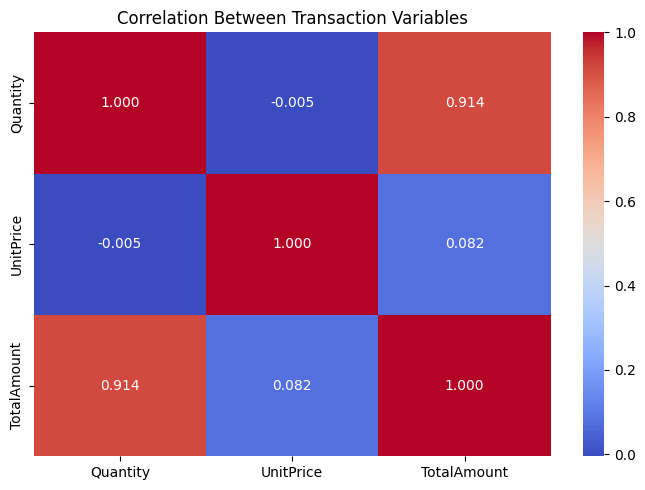

In [17]:
# Correlation analysis

correlation_data = clean_df[
    ["Quantity", "UnitPrice", "TotalAmount"]
]

correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.title("Correlation Between Transaction Variables")
plt.tight_layout()
plt.show()

In [18]:
# RFM analysis

reference_date = (
    clean_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = clean_df.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "TotalAmount",
        "sum"
    )
).reset_index()

print("RFM dataset shape:", rfm.shape)

print("\nRFM Summary:")
display(rfm.describe())

print("\nFirst 5 customers:")
display(rfm.head())

RFM dataset shape: (4338, 4)

RFM Summary:


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000



First 5 customers:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


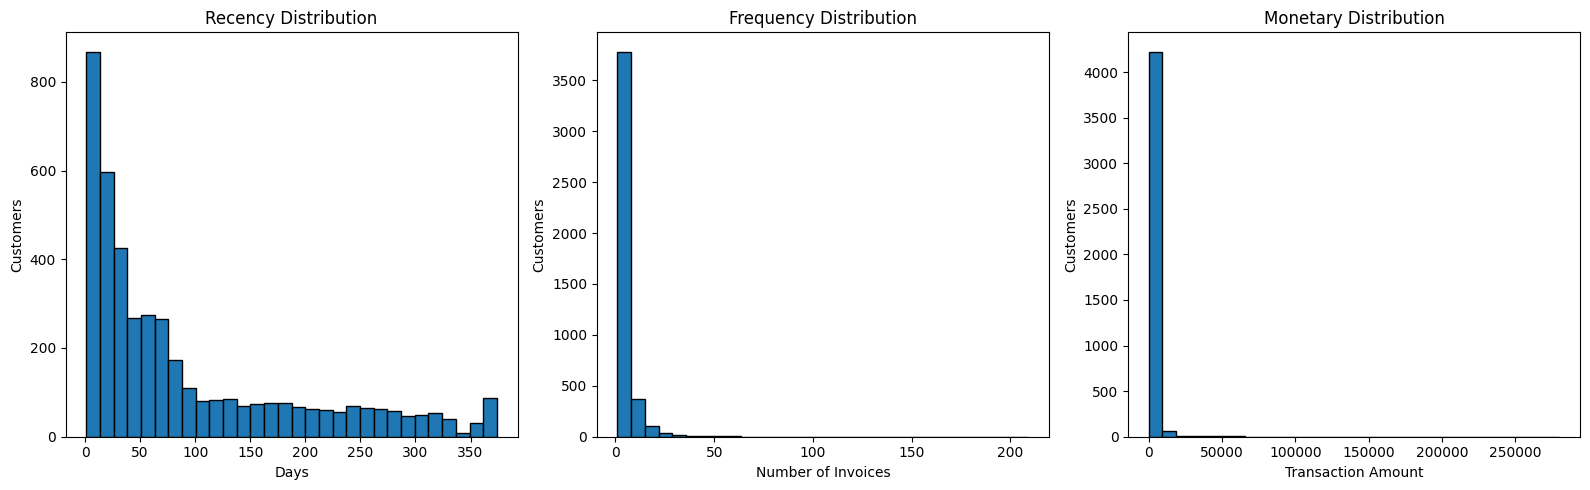

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm["Recency"], bins=30, edgecolor="black")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Customers")

axes[1].hist(rfm["Frequency"], bins=30, edgecolor="black")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Invoices")
axes[1].set_ylabel("Customers")

axes[2].hist(rfm["Monetary"], bins=30, edgecolor="black")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Transaction Amount")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [20]:
# Log transformation to reduce skewness

rfm["Recency_Log"] = np.log1p(rfm["Recency"])
rfm["Frequency_Log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_Log"] = np.log1p(rfm["Monetary"])

log_features = rfm[
    ["Recency_Log", "Frequency_Log", "Monetary_Log"]
]

print("Log transformation completed.")

print("\nTransformed feature statistics:")
display(log_features.describe())

Log transformation completed.

Transformed feature statistics:


,Recency_Log,Frequency_Log,Monetary_Log
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


In [21]:
# Standardization

scaler_rfm = StandardScaler()

rfm_scaled = scaler_rfm.fit_transform(log_features)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=log_features.columns
)

print("Means after scaling:")
print(rfm_scaled_df.mean().round(4).to_dict())

print("\nStandard deviations after scaling:")
print(rfm_scaled_df.std().round(4).to_dict())

Means after scaling:
{'Recency_Log': -0.0, 'Frequency_Log': -0.0, 'Monetary_Log': -0.0}

Standard deviations after scaling:
{'Recency_Log': 1.0001, 'Frequency_Log': 1.0001, 'Monetary_Log': 1.0001}


In [22]:
# Elbow and silhouette analysis

inertia_values = []
silhouette_values = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(
        silhouette_score(rfm_scaled, labels)
    )

print("K-value analysis completed.")

for k, inertia, silhouette in zip(
    k_values,
    inertia_values,
    silhouette_values
):
    print(
        f"K={k}: "
        f"Inertia={inertia:.2f}, "
        f"Silhouette={silhouette:.4f}"
    )

K-value analysis completed.
K=2: Inertia=6483.59, Silhouette=0.4328
K=3: Inertia=4869.49, Silhouette=0.3365
K=4: Inertia=3939.05, Silhouette=0.3375
K=5: Inertia=3296.71, Silhouette=0.3162
K=6: Inertia=2855.76, Silhouette=0.3124
K=7: Inertia=2548.82, Silhouette=0.3092
K=8: Inertia=2336.34, Silhouette=0.3033
K=9: Inertia=2156.01, Silhouette=0.2811
K=10: Inertia=2005.75, Silhouette=0.2767


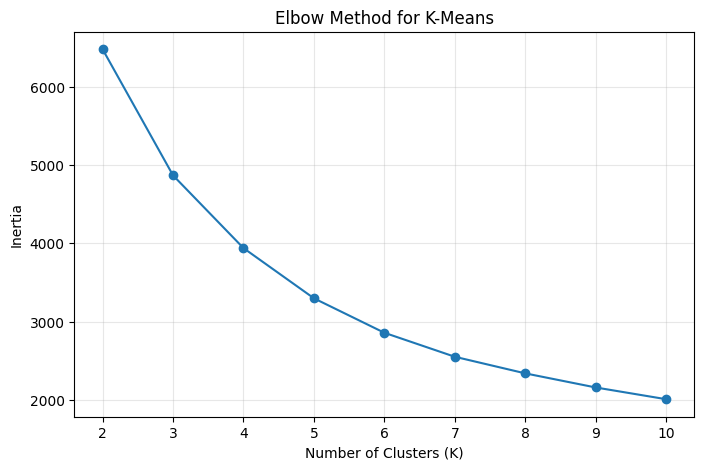

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.show()

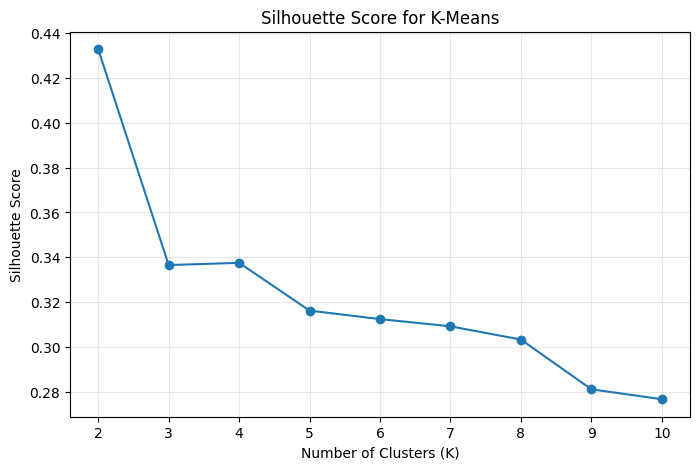

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# Final K-Means clustering

final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

final_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Final number of clusters:", final_k)
print("Final silhouette score:", round(final_silhouette, 4))

print("\nCluster counts:")
print(rfm["Cluster"].value_counts().sort_index())

Final number of clusters: 2
Final silhouette score: 0.4328

Cluster counts:
Cluster
0    2672
1    1666
Name: count, dtype: int64


In [26]:
# Cluster profiling

cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Median_Recency=("Recency", "median"),
        Avg_Frequency=("Frequency", "mean"),
        Median_Frequency=("Frequency", "median"),
        Avg_Monetary=("Monetary", "mean"),
        Median_Monetary=("Monetary", "median")
    )
    .round(2)
)

cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customers"]
    / len(rfm)
    * 100
).round(2)

print("Customer Cluster Profile:")
display(cluster_profile)

Customer Cluster Profile:


,Customers,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary,Customer_Percentage
Cluster,,,,,,,,
0,2672,134.09,96.0,1.67,1.0,495.59,363.08,61.6
1,1666,25.89,16.0,8.44,6.0,4539.60,2061.08,38.4


PCA explained variance:
PC1: 75.08 %
PC2: 18.79 %
Total: 93.87 %


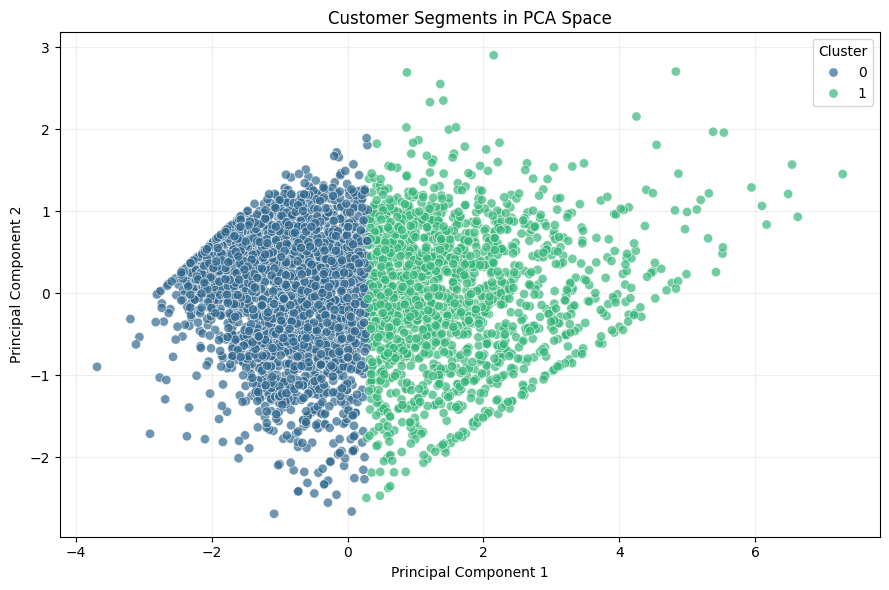

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

explained_variance = pca.explained_variance_ratio_

print("PCA explained variance:")
print("PC1:", round(explained_variance[0] * 100, 2), "%")
print("PC2:", round(explained_variance[1] * 100, 2), "%")
print(
    "Total:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis",
    s=45,
    alpha=0.7
)

plt.title("Customer Segments in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
# Temporal split for repeat-purchase prediction

cutoff_date = pd.Timestamp("2011-09-01")

historical_df = clean_df[
    clean_df["InvoiceDate"] < cutoff_date
].copy()

future_df = clean_df[
    clean_df["InvoiceDate"] >= cutoff_date
].copy()

print("Historical data shape:", historical_df.shape)
print("Future data shape:", future_df.shape)

print("\nHistorical period:")
print(
    historical_df["InvoiceDate"].min(),
    "to",
    historical_df["InvoiceDate"].max()
)

print("\nFuture period:")
print(
    future_df["InvoiceDate"].min(),
    "to",
    future_df["InvoiceDate"].max()
)

Historical data shape: (224036, 13)
Future data shape: (168656, 13)

Historical period:
2010-12-01 08:26:00 to 2011-08-31 17:16:00

Future period:
2011-09-01 08:25:00 to 2011-12-09 12:50:00


In [29]:
# Create repeat-purchase target

historical_customers = set(
    historical_df["CustomerID"].unique()
)

future_customers = set(
    future_df["CustomerID"].unique()
)

target_df = pd.DataFrame({
    "CustomerID": list(historical_customers)
})

target_df["RepeatPurchase"] = (
    target_df["CustomerID"]
    .isin(future_customers)
    .astype(int)
)

print("Target dataset shape:", target_df.shape)

print("\nTarget distribution:")
print(
    target_df["RepeatPurchase"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentage:")
print(
    target_df["RepeatPurchase"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Target dataset shape: (3317, 2)

Target distribution:
RepeatPurchase
0    1365
1    1952
Name: count, dtype: int64

Target percentage:
RepeatPurchase
0    41.15
1    58.85
Name: proportion, dtype: float64


In [30]:
# Historical customer-level feature engineering

reference_date = (
    historical_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

customer_features = historical_df.groupby(
    "CustomerID"
).agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "TotalAmount",
        "sum"
    ),
    TotalQuantity=(
        "Quantity",
        "sum"
    ),
    UniqueProducts=(
        "StockCode",
        "nunique"
    )
).reset_index()

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"]
    / customer_features["Frequency"]
)

print("Customer feature dataset shape:", customer_features.shape)

display(customer_features.head())

Customer feature dataset shape: (3317, 7)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue
0,12346,226,1,77183.60,74215,1,77183.600000
1,12347,30,5,2790.86,1590,82,558.172000
2,12348,149,3,1487.24,2124,22,495.746667
3,12350,211,1,334.40,197,17,334.400000
4,12352,163,5,1561.81,254,26,312.362000


In [31]:
# Final predictive modeling dataset

model_df = customer_features.merge(
    target_df,
    on="CustomerID",
    how="inner"
)

print("Final modeling dataset shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isnull().sum())

display(model_df.head())

Final modeling dataset shape: (3317, 8)

Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue', 'RepeatPurchase']

Missing values:
CustomerID        0
Recency           0
Frequency         0
Monetary          0
TotalQuantity     0
UniqueProducts    0
AvgOrderValue     0
RepeatPurchase    0
dtype: int64


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue,RepeatPurchase
0,12346,226,1,77183.60,74215,1,77183.600000,0
1,12347,30,5,2790.86,1590,82,558.172000,1
2,12348,149,3,1487.24,2124,22,495.746667,1
3,12350,211,1,334.40,197,17,334.400000,0
4,12352,163,5,1561.81,254,26,312.362000,1


In [32]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AvgOrderValue"
]

X = model_df[feature_columns].copy()
y = model_df["RepeatPurchase"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(feature_columns)

Feature matrix shape: (3317, 6)
Target shape: (3317,)

Features:
['Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue']


In [33]:
# Log transformation

X_log = np.log1p(X)

print("Original feature statistics:")
display(X.describe().round(2))

print("\nLog-transformed feature statistics:")
display(X_log.describe().round(2))

Original feature statistics:


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue
count,3317.00,3317.00,3317.00,3317.00,3317.00,3317.00
mean,93.11,3.44,1575.97,923.76,49.09,399.43
std,76.68,5.59,5974.01,3733.91,66.19,1435.70
min,1.00,1.00,2.90,1.00,1.00,2.90
25%,28.00,1.00,258.25,128.00,13.00,168.20
50%,73.00,2.00,552.80,305.00,29.00,283.50
75%,146.00,4.00,1355.11,767.00,62.00,412.65
max,274.00,127.00,176355.94,126731.00,1190.00,77183.60



Log-transformed feature statistics:


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue
count,3317.00,3317.00,3317.00,3317.00,3317.00,3317.00
mean,4.08,1.23,6.40,5.75,3.36,5.61
std,1.11,0.62,1.22,1.37,1.09,0.77
min,0.69,0.69,1.36,0.69,0.69,1.36
25%,3.37,0.69,5.56,4.86,2.64,5.13
50%,4.30,1.10,6.32,5.72,3.40,5.65
75%,4.99,1.61,7.21,6.64,4.14,6.03
max,5.62,4.85,12.08,11.75,7.08,11.25


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Training set: (2653, 6)
Test set: (664, 6)

Training target distribution:
RepeatPurchase
0    1092
1    1561
Name: count, dtype: int64

Test target distribution:
RepeatPurchase
0    273
1    391
Name: count, dtype: int64


In [35]:
scaler_model = StandardScaler()

X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nTraining means:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nTraining standard deviations:")
print(np.round(X_train_scaled.std(axis=0), 4))

Scaled training shape: (2653, 6)
Scaled test shape: (664, 6)

Training means:
[ 0.  0. -0. -0.  0.  0.]

Training standard deviations:
[1. 1. 1. 1. 1. 1.]


In [36]:
# Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_pred = (
    logistic_prob >= 0.5
).astype(int)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred
)

logistic_recall = recall_score(
    y_test,
    logistic_pred
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_auc, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.6852
Precision: 0.7395
Recall   : 0.7187
F1-Score : 0.7289
ROC-AUC  : 0.7344


In [37]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_prob = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

rf_pred = (
    rf_prob >= 0.5
).astype(int)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.634
Precision: 0.6869
Recall   : 0.6957
F1-Score : 0.6912
ROC-AUC  : 0.7001


In [38]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
2,Monetary,0.201359
3,TotalQuantity,0.198308
0,Recency,0.193191
5,AvgOrderValue,0.165496
4,UniqueProducts,0.161418
1,Frequency,0.080227


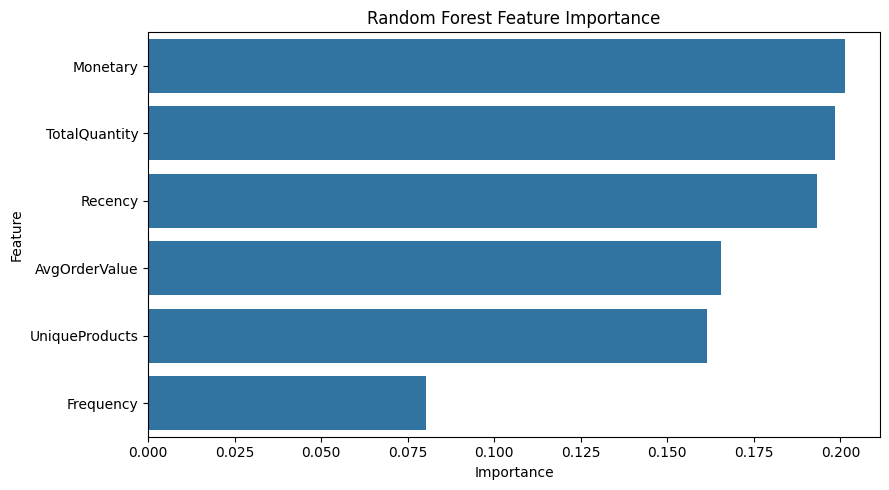

In [39]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [40]:
# Unified model comparison

ann_results = {
    "Accuracy": 0.6822,
    "Precision": 0.7394,
    "Recall": 0.7110,
    "F1-Score": 0.7249,
    "ROC-AUC": 0.7401
}

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        ann_results["Accuracy"]
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        ann_results["Precision"]
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        ann_results["Recall"]
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1,
        ann_results["F1-Score"]
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc,
        ann_results["ROC-AUC"]
    ]
})

print("Unified Model Comparison:")
display(comparison_df.round(4))

Unified Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6852,0.7395,0.7187,0.7289,0.7344
1,Random Forest,0.6340,0.6869,0.6957,0.6912,0.7001
2,Artificial Neural Network,0.6822,0.7394,0.7110,0.7249,0.7401


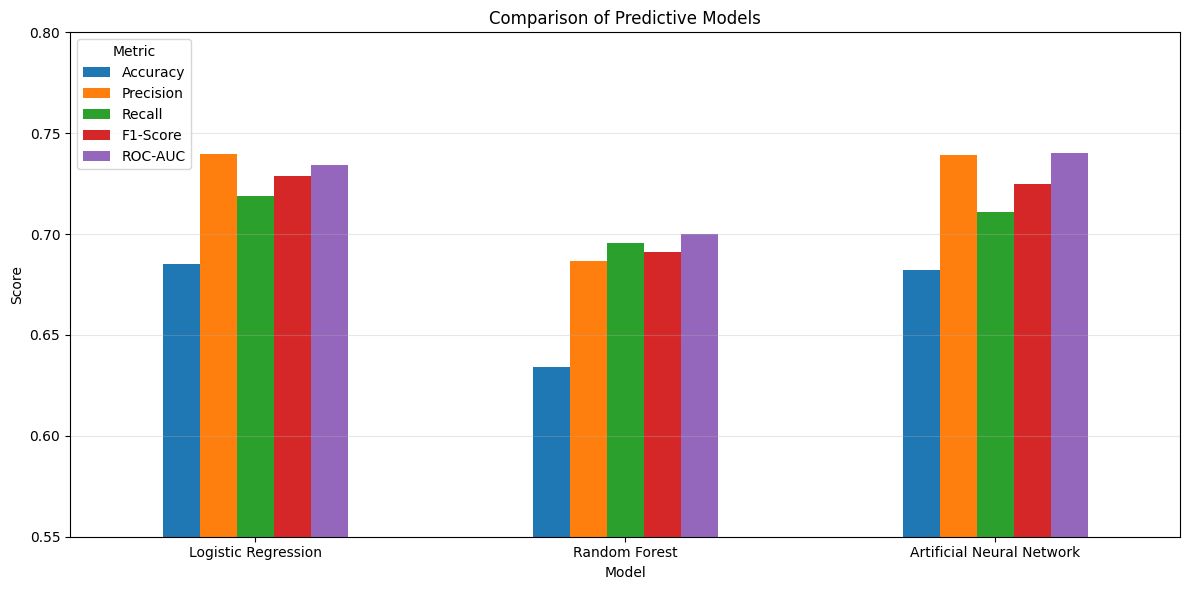

In [41]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Predictive Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.55, 0.80)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [42]:
# Final clustering evaluation

print("=== Final Clustering Evaluation ===")
print("Number of clusters:", final_k)
print("Silhouette score:", round(final_silhouette, 4))

print("\nCluster sizes:")
display(
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

=== Final Clustering Evaluation ===
Number of clusters: 2
Silhouette score: 0.4328

Cluster sizes:


,Customers
Cluster,
0,2672
1,1666


In [43]:
# Integrate customer segments with repeat-purchase behavior

segment_prediction_df = rfm[
    ["CustomerID", "Cluster"]
].merge(
    target_df,
    on="CustomerID",
    how="inner"
)

segment_summary = (
    segment_prediction_df
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Repeat_Customers=("RepeatPurchase", "sum"),
        Repeat_Rate=("RepeatPurchase", "mean")
    )
    .reset_index()
)

segment_summary["Repeat_Rate"] = (
    segment_summary["Repeat_Rate"] * 100
).round(2)

segment_summary["Non_Repeat_Customers"] = (
    segment_summary["Customers"]
    - segment_summary["Repeat_Customers"]
)

print("Customer Segment + Repeat Purchase Analysis:")
display(segment_summary)

Customer Segment + Repeat Purchase Analysis:


,Cluster,Customers,Repeat_Customers,Repeat_Rate,Non_Repeat_Customers
0,0,1841,529,28.73,1312
1,1,1476,1423,96.41,53


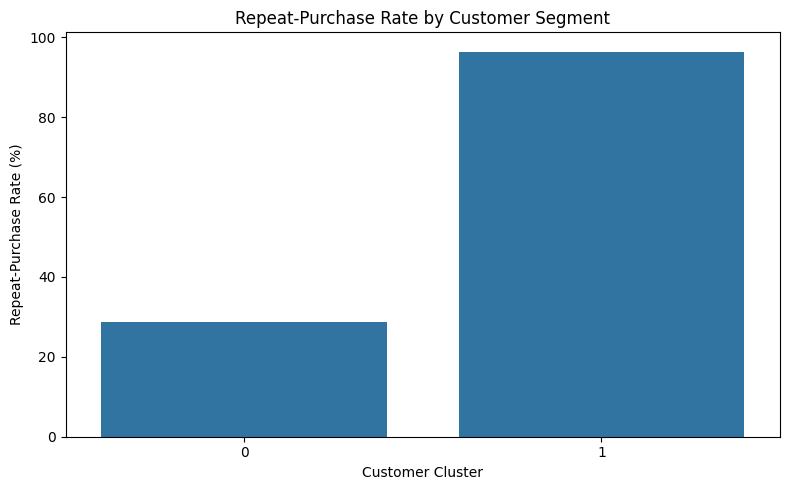

In [44]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_summary,
    x="Cluster",
    y="Repeat_Rate"
)

plt.title("Repeat-Purchase Rate by Customer Segment")
plt.xlabel("Customer Cluster")
plt.ylabel("Repeat-Purchase Rate (%)")
plt.tight_layout()
plt.show()

In [45]:
# Integrated customer profile

integrated_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

integrated_profile = integrated_profile.merge(
    segment_summary[
        ["Cluster", "Repeat_Customers", "Repeat_Rate"]
    ],
    on="Cluster",
    how="left"
)

integrated_profile = integrated_profile.round(2)

print("Integrated Customer Profile:")
display(integrated_profile)

Integrated Customer Profile:


,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Repeat_Customers,Repeat_Rate
0,0,2672,134.09,1.67,495.59,529,28.73
1,1,1666,25.89,8.44,4539.60,1423,96.41


In [46]:
# Final numerical insights

highest_revenue_month = (
    monthly_revenue.loc[
        monthly_revenue["TotalAmount"].idxmax()
    ]
)

highest_country = country_revenue.index[0]

highest_quantity_product = product_quantity.index[0]

highest_quantity_value = product_quantity.iloc[0]

highest_repeat_segment = (
    segment_summary.loc[
        segment_summary["Repeat_Rate"].idxmax()
    ]
)

print("=== FINAL CAPSTONE INSIGHTS ===")

print(
    f"1. Highest monthly transaction amount: "
    f"{highest_revenue_month['Period']} "
    f"({highest_revenue_month['TotalAmount']:,.2f})"
)

print(
    f"2. Country with highest transaction amount: "
    f"{highest_country}"
)

print(
    f"3. Highest-quantity product: "
    f"{highest_quantity_product} "
    f"({highest_quantity_value:,} units)"
)

print(
    f"4. Customer segment with higher repeat-purchase rate: "
    f"Cluster {int(highest_repeat_segment['Cluster'])} "
    f"({highest_repeat_segment['Repeat_Rate']:.2f}%)"
)

print(
    f"5. Best recorded predictive ROC-AUC: "
    f"{comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']} "
    f"({comparison_df['ROC-AUC'].max():.4f})"
)

=== FINAL CAPSTONE INSIGHTS ===
1. Highest monthly transaction amount: 2011-11 (1,156,205.61)
2. Country with highest transaction amount: United Kingdom
3. Highest-quantity product: PAPER CRAFT , LITTLE BIRDIE (80,995 units)
4. Customer segment with higher repeat-purchase rate: Cluster 1 (96.41%)
5. Best recorded predictive ROC-AUC: Artificial Neural Network (0.7401)


In [47]:
recommendations_df = pd.DataFrame({
    "Area": [
        "Customer retention",
        "Customer segmentation",
        "Marketing personalization",
        "Model deployment",
        "Model improvement"
    ],
    "Recommendation": [
        "Use customer purchase behavior and predicted repeat-purchase probability to support retention analysis.",
        "Use RFM-based segments to differentiate customer engagement and value patterns.",
        "Test personalized campaigns for customer groups with different behavioral characteristics.",
        "Use model probabilities as decision-support information rather than as automatic customer decisions.",
        "Evaluate richer temporal and product-level features and multiple time-based validation periods."
    ]
})

display(recommendations_df)

,Area,Recommendation
0,Customer retention,Use customer purchase behavior and predicted r...
1,Customer segmentation,Use RFM-based segments to differentiate custom...
2,Marketing personalization,Test personalized campaigns for customer group...
3,Model deployment,Use model probabilities as decision-support in...
4,Model improvement,Evaluate richer temporal and product-level fea...


In [48]:
# Final capstone metrics

print("========== FINAL CAPSTONE SUMMARY ==========")

print("\nDATA")
print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Customers:", clean_df["CustomerID"].nunique())
print("Products:", clean_df["StockCode"].nunique())
print("Invoices:", clean_df["InvoiceNo"].nunique())
print("Countries:", clean_df["Country"].nunique())

print("\nCLUSTERING")
print("Clusters:", final_k)
print("Silhouette Score:", round(final_silhouette, 4))

print("\nPREDICTIVE MODELING")

for _, row in comparison_df.iterrows():
    print(
        f"{row['Model']}: "
        f"Accuracy={row['Accuracy']:.4f}, "
        f"F1={row['F1-Score']:.4f}, "
        f"ROC-AUC={row['ROC-AUC']:.4f}"
    )

========== FINAL CAPSTONE SUMMARY ==========

DATA
Original rows: 541909
Cleaned rows: 392692
Customers: 4338
Products: 3665
Invoices: 18532
Countries: 37

CLUSTERING
Clusters: 2
Silhouette Score: 0.4328

PREDICTIVE MODELING
Logistic Regression: Accuracy=0.6852, F1=0.7289, ROC-AUC=0.7344
Random Forest: Accuracy=0.6340, F1=0.6912, ROC-AUC=0.7001
Artificial Neural Network: Accuracy=0.6822, F1=0.7249, ROC-AUC=0.7401


In [49]:
# Save final capstone outputs

rfm.to_csv(
    "task6_customer_segments.csv",
    index=False
)

comparison_df.to_csv(
    "task6_model_comparison.csv",
    index=False
)

segment_summary.to_csv(
    "task6_segment_repeat_purchase_analysis.csv",
    index=False
)

integrated_profile.to_csv(
    "task6_integrated_customer_profile.csv",
    index=False
)

recommendations_df.to_csv(
    "task6_recommendations.csv",
    index=False
)

clean_df.to_csv(
    "task6_cleaned_online_retail.csv",
    index=False
)

print("All Task 6 output files saved successfully.")

All Task 6 output files saved successfully.


In [50]:
from google.colab import files

files.download("task6_customer_segments.csv")
files.download("task6_model_comparison.csv")
files.download("task6_segment_repeat_purchase_analysis.csv")
files.download("task6_integrated_customer_profile.csv")
files.download("task6_recommendations.csv")
files.download("task6_cleaned_online_retail.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>